In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

We make sure that date is of type 'Datetime' and ticker is of type 'object', that there is no multiindex and that rest of columns are numerical (float)

In [3]:
DATA_PATH = "../data/processed/financial_database.parquet"

df = pd.read_parquet(DATA_PATH)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27710 entries, 0 to 27709
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 27710 non-null  datetime64[ns]
 1   open                 27710 non-null  float64       
 2   high                 27710 non-null  float64       
 3   low                  27710 non-null  float64       
 4   close                27710 non-null  float64       
 5   adj_close            27710 non-null  float64       
 6   volume               27710 non-null  int64         
 7   sma_50               27210 non-null  float64       
 8   sma_200              25710 non-null  float64       
 9   ema_20               27700 non-null  float64       
 10  price_sma_50         27210 non-null  float64       
 11  rsi_14               27560 non-null  float64       
 12  macd                 27700 non-null  float64       
 13  macd_signal          27700 non-

,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,roe,roa,revenue_growth_yoy,earnings_growth_yoy,fcf_growth_yoy,debt_to_equity,current_ratio,interest_coverage,shares_outstanding,GDP,CPIAUCSL,FEDFUNDS,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18063.529,234.747,0.11,AAPL
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18063.529,234.747,0.11,AMZN
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278946,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18063.529,234.747,0.11,GOOGL
3,2015-01-02,105.050003,105.550003,104.129997,104.519997,76.955551,5753600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18063.529,234.747,0.11,JNJ
4,2015-01-02,62.180000,62.959999,62.070000,62.490002,46.511143,12600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18063.529,234.747,0.11,JPM


We check the panel structure to ensure that the long format is correct.

In [4]:
df[["date", "ticker"]].drop_duplicates().head(10)

,date,ticker
0,2015-01-02,AAPL
1,2015-01-02,AMZN
2,2015-01-02,GOOGL
3,2015-01-02,JNJ
4,2015-01-02,JPM
5,2015-01-02,META
6,2015-01-02,MSFT
7,2015-01-02,NVDA
8,2015-01-02,TSLA
9,2015-01-02,XOM


We check the date Range

In [5]:
df.groupby("ticker")["date"].agg(["min", "max"])

,min,max
ticker,,
AAPL,2015-01-02,2026-01-08
AMZN,2015-01-02,2026-01-08
GOOGL,2015-01-02,2026-01-08
JNJ,2015-01-02,2026-01-08
JPM,2015-01-02,2026-01-08
META,2015-01-02,2026-01-08
MSFT,2015-01-02,2026-01-08
NVDA,2015-01-02,2026-01-08
TSLA,2015-01-02,2026-01-08


We check that the technical indicators are correct:
- RSI between 0 and 100
- Correct rollings in the moving averages

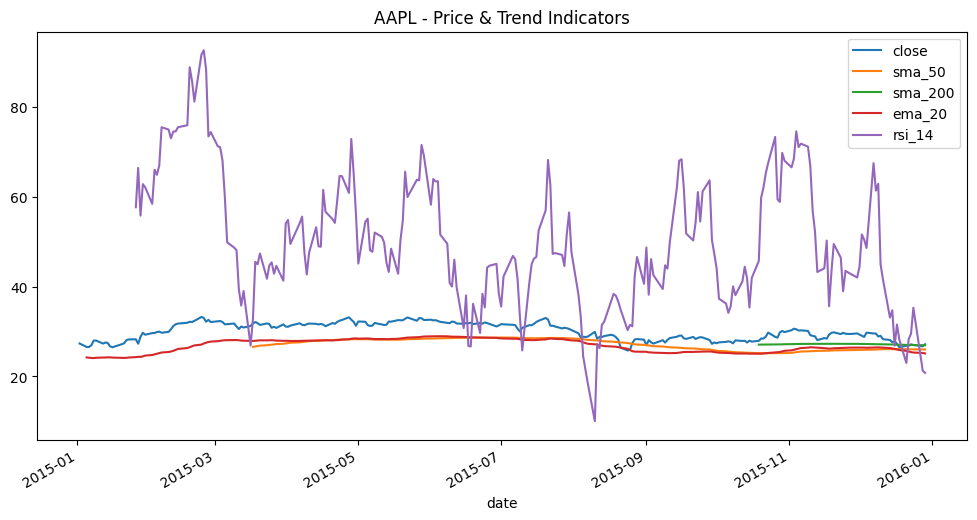

In [6]:
cols = [
    "close",
    "sma_50",
    "sma_200",
    "ema_20",
    "rsi_14"
]

aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Price & Trend Indicators")
plt.show()

In [8]:
fund_cols = [
    # "pe_trailing",
    "roe",
    "revenue_growth_yoy",
    "debt_to_equity"
]

aapl[fund_cols].dropna().head(20)

,roe,revenue_growth_yoy,debt_to_equity
date,,,
2024-12-31,0.258753,-0.073546,1.872327
2025-01-02,0.258753,-0.073546,1.872327
2025-01-03,0.258753,-0.073546,1.872327
2025-01-06,0.258753,-0.073546,1.872327
2025-01-07,0.258753,-0.073546,1.872327
2025-01-08,0.258753,-0.073546,1.872327
2025-01-10,0.258753,-0.073546,1.872327
2025-01-13,0.258753,-0.073546,1.872327
2025-01-14,0.258753,-0.073546,1.872327


In [9]:
aapl[fund_cols].dropna().tail(20)

,roe,revenue_growth_yoy,debt_to_equity
date,,,
2025-03-03,0.258753,-0.073546,1.872327
2025-03-04,0.258753,-0.073546,1.872327
2025-03-05,0.258753,-0.073546,1.872327
2025-03-06,0.258753,-0.073546,1.872327
2025-03-07,0.258753,-0.073546,1.872327
2025-03-10,0.258753,-0.073546,1.872327
2025-03-11,0.258753,-0.073546,1.872327
2025-03-12,0.258753,-0.073546,1.872327
2025-03-13,0.258753,-0.073546,1.872327


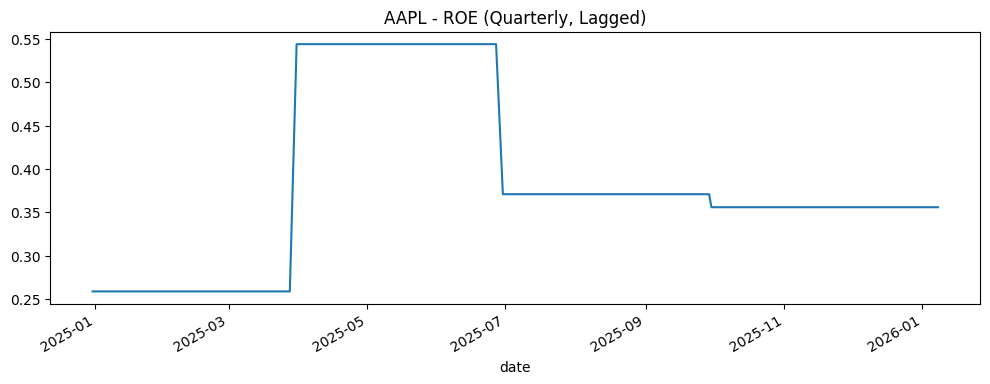

In [10]:
aapl["roe"].dropna().plot(figsize=(12,4))
plt.title("AAPL - ROE (Quarterly, Lagged)")
plt.show()

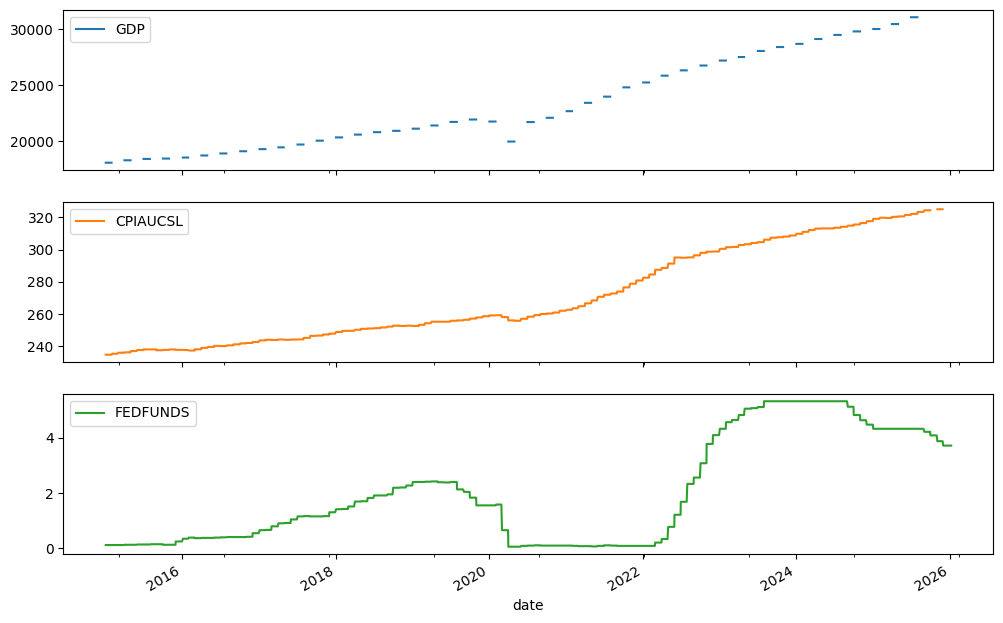

In [11]:
macro_cols = ["GDP", "CPIAUCSL", "FEDFUNDS"]

aapl[macro_cols].plot(subplots=True, figsize=(12,8))
plt.show()

In [12]:
df.isna().mean().sort_values(ascending=False).head(20)

fcf_growth_yoy         0.978311
earnings_growth_yoy    0.978311
revenue_growth_yoy     0.978311
interest_coverage      0.926813
operating_margin       0.917575
current_ratio          0.917575
debt_to_equity         0.908336
roa                    0.908336
roe                    0.908336
net_margin             0.908336
shares_outstanding     0.896788
GDP                    0.674847
sma_200                0.072176
CPIAUCSL               0.018044
sma_50                 0.018044
price_sma_50           0.018044
ret_21d                0.007939
volatility_20d         0.007578
rsi_14                 0.005413
ret_5d                 0.002165
dtype: float64

In [13]:
df.duplicated(subset=["date", "ticker"]).sum()

np.int64(0)

In [14]:
df.sample(5)

,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,roe,roa,revenue_growth_yoy,earnings_growth_yoy,fcf_growth_yoy,debt_to_equity,current_ratio,interest_coverage,shares_outstanding,GDP,CPIAUCSL,FEDFUNDS,ticker
8111,2018-03-23,76.950500,77.450996,74.767998,74.778000,74.778000,160120000,72.483110,57.202145,77.030353,1.065710,59.290383,1.871510,2.234365,0.012487,-0.023352,-0.023636,0.041809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,249.577,1.51,AMZN
14557,2020-10-13,14.296500,14.348500,14.018750,14.248250,14.204098,344604000,12.550598,8.832836,13.258341,1.129979,69.259685,0.426343,0.346670,0.025253,0.033660,0.042771,0.169469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22087.160,260.319,0.09,NVDA
27444,2025-12-01,312.950012,314.040009,308.540009,308.920013,307.532806,7727300,305.303160,275.402560,304.332986,1.020868,48.952721,-0.321473,-0.411706,0.013328,0.017683,0.049266,0.024778,0.33392,NaN,0.041989,0.003292,NaN,NaN,NaN,1.359099,NaN,NaN,2.722262e+09,NaN,NaN,3.72,JPM
1314,2015-07-13,67.889999,68.139999,67.680000,68.089996,51.349480,16175600,50.050134,NaN,50.624645,1.010291,47.161131,0.038221,0.268302,0.011272,0.014219,-0.006961,-0.011306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18401.626,238.034,0.13,JPM
8089,2018-03-20,74.220001,74.699997,73.949997,73.989998,51.839027,13003200,56.135651,55.866591,53.033829,0.925457,34.447634,-0.989705,-1.116370,0.013532,-0.012913,-0.014487,-0.027031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,249.577,1.51,XOM
